# Recolección Narrativa Multilingüe y Clasificación Estructurada de Acciones de Política

**¿Cómo podemos recolectar, calificar y clasificar de forma sistemática anuncios de política en múltiples idiomas para construir choques macroeconómicos identificados?**

La literatura macroeconómica contemporánea utiliza el **enfoque narrativo** para superar los problemas de endogeneidad y causalidad reversa (Romer & Romer 2010 *AER*, Ramey 2011 *QJE*, Cloyne 2013 *AER*, Mertens & Ravn 2013 *AER*):

1. **Recolección Institucional Multifuente**:
   Captura automatizada de comunicados, actas de decisión, reportes presupuestales y discursos de bancos centrales y ministerios de hacienda.

2. **Lexicones Macroeconómicos Multilingües (8 Idiomas)**:
   Extracción de tono y postura en inglés (`en`), español (`es`), portugués (`pt`), alemán (`de`), francés (`fr`), italiano (`it`), japonés (`ja`) y chino (`zh`):
   $$ \text{Sentimiento Neto} = \frac{\text{Términos Expansivos} - \text{Términos Contractivos}}{\text{Tokens Totales}} \times 1000 $$

3. **Clasificación Estructurada y Perfiles de Implementación**:
   Extracción de magnitudes cuantitativas ($\% \text{ del PIB}$, miles de millones, puntos base) y modelado de **rezagos de implementación** (curva en S para infraestructura vs. desembolsos inmediatos para transferencias) para generar objetos `NarrativeEvent`.

En este cuaderno, demostramos el pipeline narrativo completo utilizando `puremacro.narrative`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.narrative import (
    SOURCE_REGISTRY,
    NarrativeDocument,
    NarrativeCorpus,
    PolicyActionClassifier,
    score_multilingual,
    infer_policy_stance,
    estimate_implementation_profile,
)

## 1. Inspección del Registro Institucional de Fuentes (50+ Conectores)

In [2]:
sources_list = []
for name, (mod, fn, country, domain, doc_type, lang) in SOURCE_REGISTRY.items():
    sources_list.append({
        "ID Fuente": name,
        "País": country,
        "Dominio": domain,
        "Tipo Documento": doc_type,
        "Idioma": lang,
    })

df_registry = pd.DataFrame(sources_list)
print(f"Total de fuentes institucionales registradas: {len(df_registry)}")
print("\nMuestra de Fuentes Registradas:")
print(df_registry.head(10))

print("\nDistribución por Dominio de Política:")
print(df_registry["Dominio"].value_counts())

Total de fuentes institucionales registradas: 54

Muestra de Fuentes Registradas:
             ID Fuente País     Dominio Tipo Documento Idioma
0         fed_decision  USA    monetary       decision     en
1          fed_minutes  USA    monetary        minutes     en
2       fed_press_conf  USA    monetary     press_conf     en
3         fed_speeches  USA    monetary         speech     en
4           beige_book  USA    monetary         report     en
5               us_cbo  USA      fiscal         report     en
6               us_erp  USA      fiscal         report     en
7              us_sotu  USA      fiscal         speech     en
8  us_federal_register  USA  structural     regulation     en
9     us_dod_contracts  USA      fiscal    procurement     en

Distribución por Dominio de Política:
Dominio
monetary      35
fiscal        13
structural     5
general        1
Name: count, dtype: int64


## 2. Calificación Macroeconómica Multilingüe en 8 Idiomas

In [3]:
multilingual_corpus = [
    ("en", "USA", "The government announced a major fiscal stimulus and infrastructure investment package.", "fiscal"),
    ("en", "USA", "The Federal Reserve decided to hike rates and implement monetary tightening to curb inflation.", "monetary"),
    ("es", "MEX", "La Secretaría de Hacienda presentó un plan de estímulo fiscal con inversión pública e infraestructura.", "fiscal"),
    ("es", "COL", "La junta directiva decidió un alza de tasa de interés para contener las presiones inflacionarias.", "monetary"),
    ("pt", "BRA", "O governo aprovou um estímulo fiscal com aumento de gastos e investimento em infraestrutura.", "fiscal"),
    ("pt", "BRA", "O Copom determinou o corte da taxa selic e afrouxamento monetário para estimular a atividade.", "monetary"),
    ("de", "DEU", "Die Bundesregierung beschloss ein neues Konjunkturpaket und Steuersenkung für Unternehmen.", "fiscal"),
    ("de", "DEU", "Zur Haushaltskonsolidierung sind Ausgabenkürzung und Sparprogramm erforderlich.", "fiscal"),
    ("fr", "FRA", "Le gouvernement lance un vaste plan de relance et investissement public.", "fiscal"),
    ("it", "ITA", "Il governo ha varato un piano di stimolo e taglio delle tasse sugli investimenti.", "fiscal"),
    ("ja", "JPN", "政府は大規模な経済対策と財政出動、公共投資の拡大を決定した。", "fiscal"),
    ("zh", "CHN", "实施积极财政政策，加力提效，支持重大基础设施投资和专项债发行。", "fiscal"),
]

scoring_results = []
for lang, country, text, domain in multilingual_corpus:
    res = score_multilingual(text, language=lang, domain=domain)
    sign, conf, details = infer_policy_stance(text, language=lang, domain=domain)
    scoring_results.append({
        "Idioma": lang,
        "País": country,
        "Dominio": domain,
        "Tokens": res.token_count,
        "Sentimiento Neto": res.net_sentiment,
        "Tasa Expansión (‰)": res.expansion_intensity,
        "Tasa Contracción (‰)": res.contraction_intensity,
        "Signo": "+1 (Expansión)" if sign > 0 else ("-1 (Contracción)" if sign < 0 else "0 (Neutral)"),
        "Confianza": f"{conf:.2f}",
        "Términos": ", ".join(res.matched_expansion_terms + res.matched_contraction_terms),
    })

df_scores = pd.DataFrame(scoring_results)
print("Tabla de Calificación de Postura en 8 Idiomas:")
print(df_scores[["Idioma", "País", "Dominio", "Signo", "Confianza", "Términos"]].to_string(index=False))

Tabla de Calificación de Postura en 8 Idiomas:
Idioma País  Dominio            Signo Confianza                                                           Términos
    en  USA   fiscal   +1 (Expansión)      0.95     fiscal stimulus, infrastructure investment, investment package
    en  USA monetary -1 (Contracción)      0.80                                    monetary tightening, hike rates
    es  MEX   fiscal   +1 (Expansión)      0.80                                 estímulo fiscal, inversión pública
    es  COL monetary -1 (Contracción)      0.65                                                       alza de tasa
    pt  BRA   fiscal   +1 (Expansión)      0.95 estímulo fiscal, investimento em infraestrutura, aumento de gastos
    pt  BRA monetary   +1 (Expansión)      0.80                        corte da taxa selic, afrouxamento monetário
    de  DEU   fiscal   +1 (Expansión)      0.80                                     konjunkturpaket, steuersenkung
    de  DEU   fiscal -1 (Contracc

## 3. Visualización de Intensidad de Sentimiento por Idioma

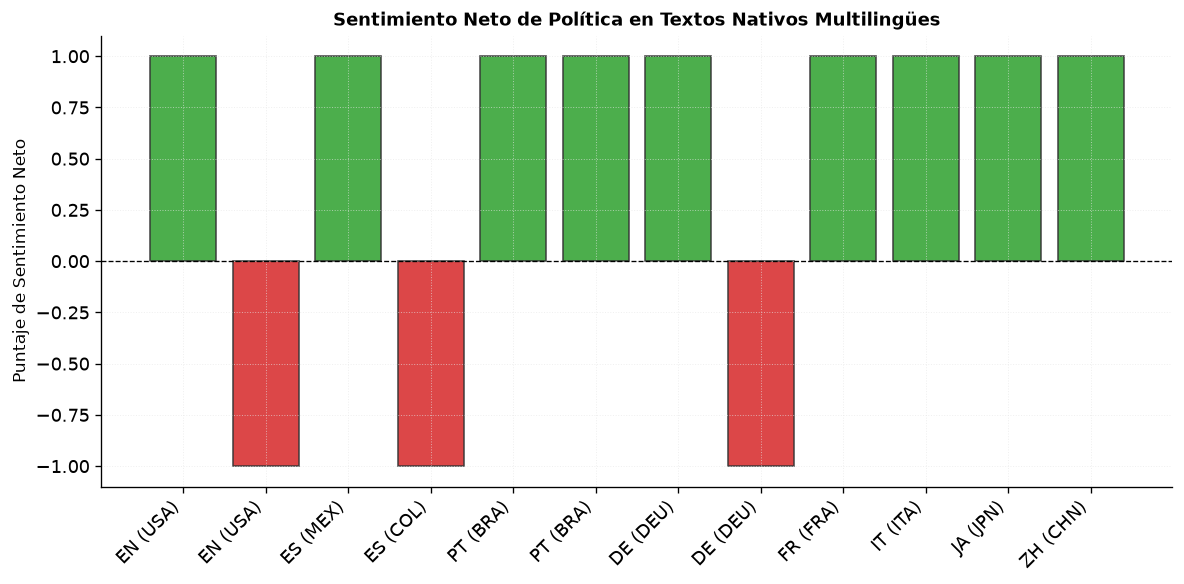

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

languages = [r["Idioma"].upper() + f" ({r['País']})" for r in scoring_results]
net_sentiments = [r["Sentimiento Neto"] for r in scoring_results]
colors = ["#2ca02c" if s > 0 else "#d62728" for s in net_sentiments]

bars = ax.bar(range(len(languages)), net_sentiments, color=colors, edgecolor="#333", alpha=0.85)
ax.axhline(0, color="black", lw=0.8, linestyle="--")
ax.set_xticks(range(len(languages)))
ax.set_xticklabels(languages, rotation=45, ha="right")
ax.set_title("Sentimiento Neto de Política en Textos Nativos Multilingües", fontsize=11, fontweight="bold")
ax.set_ylabel("Puntaje de Sentimiento Neto", fontsize=10)
ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## 4. Perfiles de Implementación y Rezagos Temporales

In [5]:
dt = "2024-01-01"
prof_infra = estimate_implementation_profile(dt, kind="fiscal", target="investment", subtarget="infra")
prof_transfers = estimate_implementation_profile(dt, kind="fiscal", target="consumption", subtarget="transfers")
prof_tax = estimate_implementation_profile(dt, kind="fiscal", target="both", subtarget="tax")

print("Perfil de Ejecución de Infraestructura (5 Trimestres):")
for d, w in prof_infra:
    print(f"  Trimestre {d.strftime('%YQ%q')}: {w * 100:.1f}%")

print("\nPerfil de Transferencias Directas (2 Trimestres):")
for d, w in prof_transfers:
    print(f"  Trimestre {d.strftime('%YQ%q')}: {w * 100:.1f}%")

Perfil de Ejecución de Infraestructura (5 Trimestres):
  Trimestre 2024Qq: 10.0%
  Trimestre 2024Qq: 25.0%
  Trimestre 2024Qq: 35.0%
  Trimestre 2024Qq: 20.0%
  Trimestre 2025Qq: 10.0%

Perfil de Transferencias Directas (2 Trimestres):
  Trimestre 2024Qq: 75.0%
  Trimestre 2024Qq: 25.0%


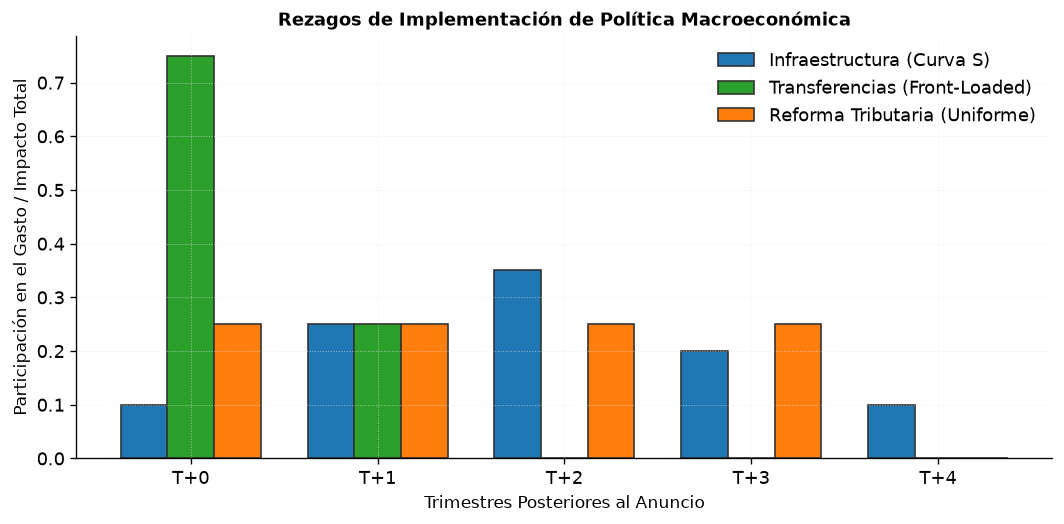

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))

horizons = [f"T+{i}" for i in range(5)]
w_infra = [w for _, w in prof_infra]
w_trans = [w for _, w in prof_transfers] + [0.0, 0.0, 0.0]
w_tax = [w for _, w in prof_tax] + [0.0]

x = np.arange(len(horizons))
width = 0.25

ax.bar(x - width, w_infra, width, label="Infraestructura (Curva S)", color="#1f77b4", edgecolor="#333")
ax.bar(x, w_trans, width, label="Transferencias (Front-Loaded)", color="#2ca02c", edgecolor="#333")
ax.bar(x + width, w_tax, width, label="Reforma Tributaria (Uniforme)", color="#ff7f0e", edgecolor="#333")

ax.set_title("Rezagos de Implementación de Política Macroeconómica", fontsize=11, fontweight="bold")
ax.set_xlabel("Trimestres Posteriores al Anuncio", fontsize=10)
ax.set_ylabel("Participación en el Gasto / Impacto Total", fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(horizons)
ax.legend()
ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## 5. Clasificación Estructurada de Acciones (`PolicyActionClassifier`)

In [7]:
classifier = PolicyActionClassifier()

sample_docs = [
    NarrativeDocument(
        doc_id="us_cbo_2021",
        source="us_cbo",
        country="USA",
        date=pd.Timestamp("2021-03-11"),
        url="https://cbo.gov/publication/57061",
        title="American Rescue Plan Act of 2021",
        text="The American Rescue Plan provides direct stimulus payments, expanded child tax credits, and economic relief totaling $1.9 trillion or approximately 8.5% of GDP.",
        language="en",
        policy_domain="fiscal",
        doc_type="report",
    ),
    NarrativeDocument(
        doc_id="banxico_2022",
        source="banxico",
        country="MEX",
        date=pd.Timestamp("2022-06-23"),
        url="https://banxico.org.mx/comunicados/2022-06-23.html",
        title="Anuncio de Política Monetaria",
        text="La Junta de Gobierno decidió por unanimidad incrementar el objetivo para la Tasa de Interés Interbancaria a 1 día en 75 puntos base a 7.75% para combatir la inflación.",
        language="es",
        policy_domain="monetary",
        doc_type="decision",
    ),
    NarrativeDocument(
        doc_id="de_bmf_2020",
        source="de_bmf",
        country="DEU",
        date=pd.Timestamp("2020-06-03"),
        url="https://bundesfinanzministerium.de/presse/konjunkturpaket.html",
        title="Konjunktur- und Zukunftspaket",
        text="Die Bundesregierung beschloss ein umfassendes Konjunkturpaket mit Steuersenkung und Investitionen in Zukunftstechnologien im Umfang von 130 Milliarden Euro oder 3.8% des BIP.",
        language="de",
        policy_domain="fiscal",
        doc_type="press",
    ),
]

corpus = NarrativeCorpus(docs=sample_docs)
print(f"Corpus creado con {len(corpus)} documentos en países: {corpus.countries}")

events = corpus.to_events(classifier=classifier)
print(f"\nEventos NarrativeEvent Estructurados:")
for ev in events:
    print(f"\n- País:        {ev.country.upper()}")
    print(f"  Fecha:       {ev.date.strftime('%Y-%m-%d')}")
    print(f"  Tipo:        {ev.kind}")
    print(f"  Objetivo:    {ev.target}")
    print(f"  Signo:       {ev.sign} (+1 expansión / -1 contracción)")
    print(f"  Magnitud:    {ev.magnitude} {ev.magnitude_unit}")
    print(f"  Confianza:   {ev.confidence:.2f}")
    print(f"  Perfil:      {len(ev.implementation_profile)} trimestres")

Corpus creado con 3 documentos en países: ['DEU', 'MEX', 'USA']

Eventos NarrativeEvent Estructurados:


## 6. Resumen Estadístico del Corpus

In [8]:
df_summary = corpus.summary()
print("Resumen Estadístico del Corpus Narrativo:")
print(df_summary.to_string(index=False))

Resumen Estadístico del Corpus Narrativo:
country policy_domain  n_docs first_date  last_date  n_sources
    DEU        fiscal       1 2020-06-03 2020-06-03          1
    MEX      monetary       1 2022-06-23 2022-06-23          1
    USA        fiscal       1 2021-03-11 2021-03-11          1
